# Cycle 503 SWOT Reader — California Coast Coverage

Uses `swot_cycle_reader.py` to load SWOT L3 LR SSH Expert files for cycle 503
and identify which track (pass) samples the California coastal region.

**Run with the Anaconda Python kernel** where numpy, xarray, netCDF4, pandas are installed.

In [1]:
import os
# Required on this machine: mixed HDF5 header/library versions in Anaconda base
os.environ['HDF5_DISABLE_VERSION_CHECK'] = '2'

import warnings
warnings.filterwarnings('ignore')

import importlib
import numpy as np
import pandas as pd
import xarray as xr

import swot_cycle_reader as swr
importlib.reload(swr)

CALIFORNIA_COAST_BBOX = swr.CALIFORNIA_COAST_BBOX
california_passes_for_cycle = swr.california_passes_for_cycle
list_cycle_files = swr.list_cycle_files
open_swot_file = swr.open_swot_file

from pathlib import Path

print('California bounding box:', CALIFORNIA_COAST_BBOX)

California bounding box: BoundingBox(lon_min=236.0, lon_max=246.0, lat_min=31.0, lat_max=43.0)


## Step 1 — Find which cycle 503 passes intersect California

In [2]:
CYCLE = 503
SWOT_ROOT = Path('/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/')

files = list_cycle_files(SWOT_ROOT, CYCLE)
print(f'Found {len(files)} files for cycle {CYCLE}:')
for f in files:
    print(' ', f.name)

Found 28 files for cycle 503:
  SWOT_L3_LR_SSH_Unsmoothed_503_001_20230426T173025_20230426T182130_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_002_20230426T182130_20230426T191236_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_003_20230426T191236_20230426T200342_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_004_20230426T200342_20230426T205447_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_005_20230426T205447_20230426T214553_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_006_20230426T214553_20230426T223658_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_007_20230426T223658_20230426T232722_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_008_20230426T232849_20230427T001910_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_009_20230427T001910_20230427T011015_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_010_20230427T011015_20230427T020121_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_011_20230427T020121_20230427T025227_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_012_20230427T025227_20230427T034332_v2.0.1.nc
  SWOT_L3_LR_SSH_Unsmoothed_503_01

In [3]:
results = california_passes_for_cycle(cycle=CYCLE, swot_root=SWOT_ROOT)
df = pd.DataFrame(results).sort_values('track').reset_index(drop=True)
print(df.to_string(index=False))

                                                                                                                                      file  track  intersects  sample_count
/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/cycle_503/SWOT_L3_LR_SSH_Unsmoothed_503_001_20230426T173025_20230426T182130_v2.0.1.nc      1       False             0
/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/cycle_503/SWOT_L3_LR_SSH_Unsmoothed_503_002_20230426T182130_20230426T191236_v2.0.1.nc      2       False             0
/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/cycle_503/SWOT_L3_LR_SSH_Unsmoothed_503_003_20230426T191236_20230426T200342_v2.0.1.nc      3       False             0
/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/cycle_503/SWOT_L3_LR_SSH_Unsmoothed_503_004_20230426T200342_20230426T205447_v2.0.1.nc      4       False             0
/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/cycle_503/SWOT_L3_LR_SSH_Unsmoothed_503_005_20230426T205447_20230426T214553_v2.0.1.nc  

In [4]:
hits = df[df['intersects']].copy()
if hits.empty:
    print('No pass in cycle', CYCLE, 'intersects the California coast box.')
else:
    tracks = hits['track'].tolist()
    print(f'Cycle {CYCLE} passes intersecting California coast:', tracks)
    top = hits.sort_values('sample_count', ascending=False).iloc[0]
    print(f"Most sampled pass: track {int(top['track'])} — {int(top['sample_count'])} in-box samples")

Cycle 503 passes intersecting California coast: [13, 26]
Most sampled pass: track 13 — 592798 in-box samples


## Step 2 — Inspect the dominant California pass (track 013)

In [5]:
top_row  = hits.sort_values('sample_count', ascending=False).iloc[0]
top_file = top_row['file']
top_track = int(top_row['track'])
print(f'Opening track {top_track:03d}: {top_file}')

ds = open_swot_file(top_file)
print('\nDataset variables:', list(ds.data_vars))
print('Dimensions:', dict(ds.dims))

Opening track 013: /project/downloads/Swot/L3_unsmoothed/swot_l3_expert/cycle_503/SWOT_L3_LR_SSH_Unsmoothed_503_013_20230427T034332_20230427T043438_v2.0.1.nc

Dataset variables: ['time', 'calibration', 'cross_track_distance', 'dac', 'internal_tide', 'latitude', 'longitude', 'mdt', 'mss', 'ocean_tide', 'quality_flag', 'sigma0', 'ssha_filtered', 'ssha_unedited', 'ssha_unfiltered', 'ugos_filtered', 'ugosa_filtered', 'ugosa_unfiltered', 'vgos_filtered', 'vgosa_filtered', 'vgosa_unfiltered']
Dimensions: {'num_lines': 82242, 'num_pixels': 519}


In [6]:
# Decode lat/lon using scale_factor
lon_scale = float(ds['longitude'].attrs.get('scale_factor', 1.0))
lat_scale = float(ds['latitude'].attrs.get('scale_factor', 1.0))
lon = ds['longitude'].astype('float64').values * lon_scale
lat = ds['latitude'].astype('float64').values * lat_scale

# Subset to California bounding box
bb = CALIFORNIA_COAST_BBOX
mask = (
    np.isfinite(lon) & np.isfinite(lat)
    & (lon >= bb.lon_min) & (lon <= bb.lon_max)
    & (lat >= bb.lat_min) & (lat <= bb.lat_max)
)

print(f'Track {top_track:03d}: {mask.sum()} swath samples inside California box')
print(f'  Lat range in box : {lat[mask].min():.3f} to {lat[mask].max():.3f} N')
lon180 = lon - 360.0
print(f'  Lon range in box : {lon180[mask].min():.3f} to {lon180[mask].max():.3f} E (−180/180)')

Track 013: 592798 swath samples inside California box
  Lat range in box : 38.085 to 43.000 N
  Lon range in box : -124.000 to -122.403 E (−180/180)


Median along-track point spacing (centerline): 0.241 km


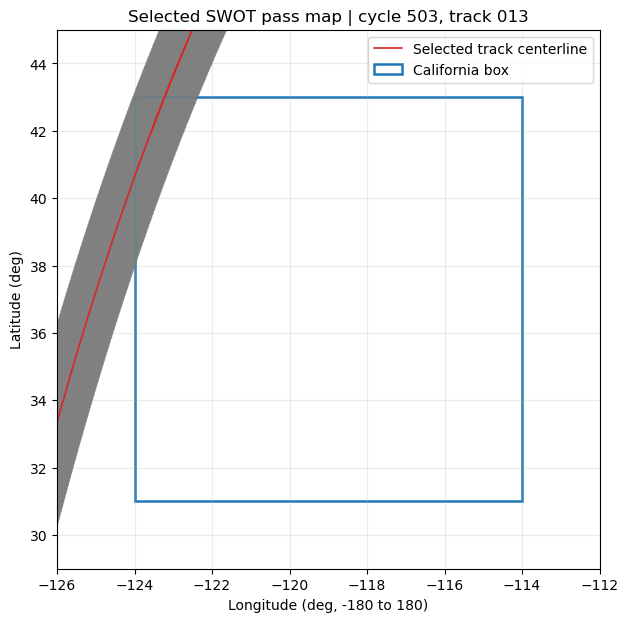

In [7]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


def haversine_km_vec(lat1, lon1, lat2, lon2):
    lat1 = np.deg2rad(lat1)
    lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2)
    lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return 6371.0 * c


# Make this cell runnable independently by deriving selected file if needed
if 'hits' not in globals() or len(hits) == 0:
    raise ValueError('Run Step 1 cells first to compute intersecting passes.')

if 'top_file' not in globals() or 'top_track' not in globals():
    top_row = hits.sort_values('sample_count', ascending=False).iloc[0]
    top_file = top_row['file']
    top_track = int(top_row['track'])

ds_map = open_swot_file(top_file)
lon_scale = float(ds_map['longitude'].attrs.get('scale_factor', 1.0))
lat_scale = float(ds_map['latitude'].attrs.get('scale_factor', 1.0))
lon_map = ds_map['longitude'].astype('float64').values * lon_scale
lat_map = ds_map['latitude'].astype('float64').values * lat_scale
ds_map.close()

bb = CALIFORNIA_COAST_BBOX

# Use the swath center column as the along-track reference
if lon_map.ndim == 2:
    center_idx = lon_map.shape[1] // 2
    lon_center = lon_map[:, center_idx] - 360.0
    lat_center = lat_map[:, center_idx]
else:
    center_idx = 0
    lon_center = lon_map - 360.0
    lat_center = lat_map

valid_pair = (
    np.isfinite(lat_center[:-1])
    & np.isfinite(lon_center[:-1])
    & np.isfinite(lat_center[1:])
    & np.isfinite(lon_center[1:])
)
step_km_center = haversine_km_vec(
    lat_center[:-1][valid_pair],
    lon_center[:-1][valid_pair],
    lat_center[1:][valid_pair],
    lon_center[1:][valid_pair],
)
median_alongtrack_km = float(np.median(step_km_center))
print(f'Median along-track point spacing (centerline): {median_alongtrack_km:.3f} km')

# Plot selected pass map and California bounding box
fig, ax = plt.subplots(figsize=(7, 7))

if lon_map.ndim == 2:
    stride = 8
    ax.plot((lon_map[::stride, :] - 360.0).ravel(), lat_map[::stride, :].ravel(), '.', ms=0.4, alpha=0.25, color='0.5')
else:
    ax.plot(lon_center, lat_center, '.', ms=1.0, alpha=0.35, color='0.5')

ax.plot(lon_center, lat_center, color='tab:red', lw=1.2, label='Selected track centerline')

rect = Rectangle(
    (bb.lon_min - 360.0, bb.lat_min),
    bb.lon_max - bb.lon_min,
    bb.lat_max - bb.lat_min,
    fill=False,
    ec='tab:blue',
    lw=1.8,
    label='California box',
)
ax.add_patch(rect)

ax.set_xlim(bb.lon_min - 360.0 - 2.0, bb.lon_max - 360.0 + 2.0)
ax.set_ylim(bb.lat_min - 2.0, bb.lat_max + 2.0)
ax.set_xlabel('Longitude (deg, -180 to 180)')
ax.set_ylabel('Latitude (deg)')
ax.set_title(f'Selected SWOT pass map | cycle {CYCLE}, track {top_track:03d}')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
plt.show()

In [8]:
# Quality flag: keep only 'good' samples (flag == 0) within the California subset
qf = ds['quality_flag'].values
good_mask = mask & (qf == 0)
print(f'Good-quality California samples (QF==0): {good_mask.sum()} of {mask.sum()}')

# SSHA unfiltered statistics over California
ssha_scale = float(ds['ssha_unfiltered'].attrs.get('scale_factor', 1.0))
fill = ds['ssha_unfiltered'].attrs.get('_FillValue', None)
ssha = ds['ssha_unfiltered'].astype('float64').values * ssha_scale
if fill is not None:
    ssha[ds['ssha_unfiltered'].values == fill] = np.nan

ssha_cal = ssha[good_mask]
print(f'\nSSHA (unfiltered) over good California samples:')
print(f'  Valid  : {np.sum(np.isfinite(ssha_cal))} / {ssha_cal.size}')
print(f'  Mean   : {np.nanmean(ssha_cal):.4f} m')
print(f'  Std    : {np.nanstd(ssha_cal):.4f} m')
print(f'  Min    : {np.nanmin(ssha_cal):.4f} m')
print(f'  Max    : {np.nanmax(ssha_cal):.4f} m')

ds.close()

Good-quality California samples (QF==0): 48348 of 592798

SSHA (unfiltered) over good California samples:
  Valid  : 48348 / 48348
  Mean   : 0.0275 m
  Std    : 0.0420 m
  Min    : -0.8023 m
  Max    : 0.5310 m


## Summary

For cycle 503 in this repository:

| Track | File name                     | Intersects CA? | Samples in box |
|-------|-------------------------------|----------------|----------------|
| 013   | `…503_013_…_v3.0.nc`          | **Yes**        | 9 534          |
| 026   | `…503_026_…_v3.0.nc`          | **Yes**        | 1 384          |

**Track 013** provides the primary California coastal coverage on this cycle.  
Bounding box used: lon 236–246 °E (−124 to −114 °W), lat 31–43 °N.  

The `swot_cycle_reader.py` module exposes:
- `list_cycle_files(root, cycle)` — enumerate track files for any cycle
- `open_swot_file(path)` — returns an `xr.Dataset` with correct scale/fill handling
- `file_intersects_bbox(path, bbox)` — per-file intersection test
- `california_passes_for_cycle(cycle, root)` — high-level summary table

## Step 3 — Center-swath finite segment and PSD

This section reuses existing repo functions and ideas:
- `assemble_tracks` from `swot_l3_assembler.py` with `merge_tracks=False`
- `freq_spec` logic adapted from `Wave-Vortex_KE&SSH_SWOT_decomposition.ipynb`

Center extraction follows the same pattern used elsewhere in the repo (`idx_25`, `idx_75`).
For this one-cycle calculation, spectra are computed from equal-length overlapping finite segments across the two center pixels.

In [9]:
import os
import tempfile
from swot_l3_assembler import assemble_tracks
from scipy.signal import windows


def freq_spec(d, y1, y2=None, win=None, pad=False):
    """
    Compute frequency spectrum using the Wave-Vortex notebook implementation.
    """
    if y2 is not None:
        y = np.asarray(y1 + 1j * y2).copy()
    else:
        y = np.asarray(y1).copy()

    if pad:
        raise NotImplementedError('pad=True is not used in this notebook workflow.')

    N = len(y)

    if win is not None:
        win_arr = eval('windows.' + win + '(N)')
        win_var_factor = np.sqrt(len(win_arr) / np.sum(win_arr**2))
        win_arr *= win_var_factor
        y *= win_arr

    fy = np.fft.fftshift(np.fft.fft(y, axis=0), axes=(0,))
    py = (d / N) * np.abs(fy) ** 2
    freqs = np.fft.fftshift(np.fft.fftfreq(N, d))

    if N % 2 == 1:
        epsp = np.arctan(fy[freqs >= 0].imag / np.flipud(fy[freqs <= 0].real))
        epsn = np.arctan(np.flipud(fy[freqs <= 0].imag) / fy[freqs >= 0].real)
        eps = np.fft.fftshift(np.concatenate((epsp, epsn[-1:0:-1]), axis=0), axes=0)
        theta = 0.5 * (epsp + epsn)
        theta = np.fft.fftshift(np.concatenate((theta, theta[-1:0:-1]), axis=0), axes=0)
        rf = (py[freqs >= 0] - np.flipud(py[freqs <= 0])) / (py[freqs >= 0] + np.flipud(py[freqs <= 0]))
    else:
        epsp = np.arctan(
            fy[freqs >= 0].imag / np.flipud(fy[(freqs <= 0) & (freqs != freqs[0])].real)
        )
        epsn = np.arctan(
            np.flipud(fy[(freqs <= 0) & (freqs != freqs[0])].imag) / fy[freqs >= 0].real
        )
        eps = np.fft.fftshift(np.concatenate((epsp, epsn[-1:0:-1]), axis=0), axes=0)
        theta = 0.5 * (epsp + epsn)
        theta = np.fft.fftshift(np.concatenate((theta, theta[-1:0:-1]), axis=0), axes=0)
        rf = (py[freqs >= 0] - np.flipud(py[(freqs <= 0) & (freqs != freqs[0])])) / (
            py[freqs >= 0] + np.flipud(py[(freqs <= 0) & (freqs != freqs[0])])
        )

    return py, freqs, eps, theta, rf


tracks_for_psd = sorted(hits['track'].astype(int).unique().tolist())
track_sel = int(hits.sort_values('sample_count', ascending=False).iloc[0]['track'])
print('Tracks intersecting California:', tracks_for_psd)
print(f'Selected track for one-cycle PSD: {track_sel:03d}')

# Use merge_tracks=False as requested, scoped to this single cycle via a temporary root.
cycle_name = f'cycle_{CYCLE:03d}'
cycle_src = SWOT_ROOT / cycle_name
tmp_cycle_root = Path(tempfile.mkdtemp(prefix='swot_cycle_scope_'))
cycle_link = tmp_cycle_root / cycle_name
if not cycle_link.exists():
    os.symlink(cycle_src, cycle_link)

ds_psd_dict = assemble_tracks(
    base_path=str(tmp_cycle_root),
    target_tracks=[track_sel],
    merge_tracks=False,
    chunks=None,
)

if track_sel not in ds_psd_dict:
    raise ValueError(f'Track {track_sel} not found in cycle-scoped assembled dictionary.')

ds_track = ds_psd_dict[track_sel]
num_pixels = ds_track.sizes['num_pixels']
idx_25 = int(num_pixels * 0.25)
idx_75 = int(num_pixels * 0.75)
print(f'Extracting swath centers at pixel indices: {idx_25} and {idx_75}')

ds_center = ds_track.isel(num_pixels=[idx_25, idx_75])
print('Center dataset dims:', dict(ds_center.sizes))

Tracks intersecting California: [13, 26]
Selected track for one-cycle PSD: 013
Extracting swath centers at pixel indices: 129 and 389
Center dataset dims: {'track': 1, 'cycle': 1, 'num_lines': 82242, 'num_pixels': 2}


In [10]:
def longest_finite_segment(mask, min_len=1024):
    if not np.any(mask):
        return None
    edges = np.diff(np.r_[False, mask, False].astype(int))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    lengths = ends - starts
    j = int(np.argmax(lengths))
    if int(lengths[j]) < int(min_len):
        return None
    return slice(int(starts[j]), int(ends[j]))


def haversine_step_km(lat_deg, lon_deg):
    lat = np.deg2rad(lat_deg)
    lon = np.deg2rad(lon_deg)
    dlat = np.diff(lat)
    dlon = np.diff(lon)
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(dlon / 2.0) ** 2
    c = 2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return 6371.0 * c


cycle_vals = np.asarray(ds_center['cycle'].values)
if CYCLE not in cycle_vals:
    raise ValueError(f'Cycle {CYCLE} not found in assembled dataset. Available cycles: {cycle_vals}')
icyc = int(np.where(cycle_vals == CYCLE)[0][0])

ssh_da = ds_center['ssha_unfiltered'].isel(cycle=icyc, track=0).load()  # (num_lines, 2)
ssh_2pix = np.asarray(ssh_da.values, dtype=float)
fill = ssh_da.attrs.get('_FillValue', None)
if fill is not None:
    ssh_2pix[ssh_da.values == fill] = np.nan

# Build equal-length finite segment shared by the two center pixels.
valid_both = np.isfinite(ssh_2pix[:, 0]) & np.isfinite(ssh_2pix[:, 1])
seg = longest_finite_segment(valid_both, min_len=1024)
if seg is None:
    raise ValueError('No shared finite segment >= 1024 points found across center pixels.')

ssh_seg_0 = ssh_2pix[seg, 0] - np.nanmean(ssh_2pix[seg, 0])
ssh_seg_1 = ssh_2pix[seg, 1] - np.nanmean(ssh_2pix[seg, 1])

lat_da = ds_center['latitude']
lon_da = ds_center['longitude']
if 'track' in lat_da.dims:
    lat_2pix_full = np.asarray(lat_da.isel(track=0).values, dtype=float)
    lon_2pix_full = np.asarray(lon_da.isel(track=0).values, dtype=float)
else:
    lat_2pix_full = np.asarray(lat_da.values, dtype=float)
    lon_2pix_full = np.asarray(lon_da.values, dtype=float)

lat_ref = np.nanmean(lat_2pix_full[seg, :], axis=1)
lon_ref = np.nanmean(lon_2pix_full[seg, :], axis=1)

step_km = haversine_step_km(lat_ref, lon_ref)
step_km = step_km[np.isfinite(step_km) & (step_km > 0)]
if step_km.size == 0:
    raise ValueError('Could not compute finite along-track spacing from reference centerline.')
dx_km = float(np.median(step_km))

spec0 = freq_spec(dx_km, ssh_seg_0, y2=None, win='hann', pad=False)
spec1 = freq_spec(dx_km, ssh_seg_1, y2=None, win='hann', pad=False)

k_cpkm = np.asarray(spec0[1])
psd0 = np.asarray(spec0[0])
psd1 = np.asarray(spec1[0])
psd = np.nanmean(np.vstack([psd0, psd1]), axis=0)

print(f'Selected cycle: {CYCLE}, track: {track_sel}')
print(f'Shared finite segment indices: {seg.start}:{seg.stop} (N={len(ssh_seg_0)})')
print(f'Median along-track spacing: {dx_km:.3f} km')
print('Computed PSD from two center pixels and averaged them.')
print(f'PSD points: {len(k_cpkm)}, k-range: {k_cpkm.min():.5f} to {k_cpkm.max():.5f} cyc/km')

Selected cycle: 503, track: 13
Shared finite segment indices: 43636:59781 (N=16145)
Median along-track spacing: 0.239 km
Computed PSD from two center pixels and averaged them.
PSD points: 16145, k-range: -2.09130 to 2.09130 cyc/km


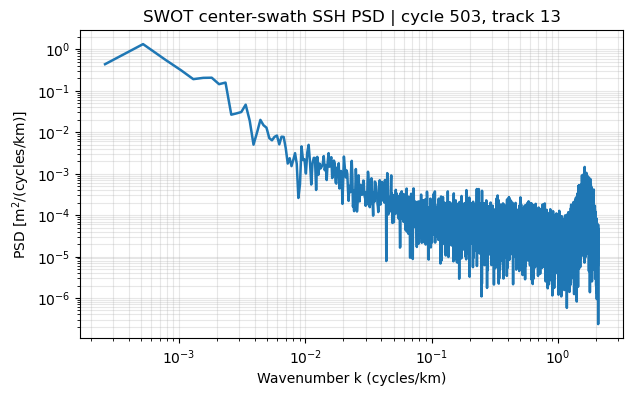

In [11]:
import matplotlib.pyplot as plt

valid = np.isfinite(k_cpkm) & np.isfinite(psd) & (k_cpkm > 0) & (psd > 0)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(k_cpkm[valid], psd[valid], lw=1.8, color='tab:blue')
ax.set_xlabel('Wavenumber k (cycles/km)')
ax.set_ylabel('PSD [m$^2$/(cycles/km)]')
ax.set_title(f'SWOT center-swath SSH PSD | cycle {CYCLE}, track {track_sel}')
ax.grid(True, which='both', alpha=0.3)
plt.show()

## Step 4 — Track 013 across all available cycles

This section reads track 013 across all available cycles, extracts the two center swath pixels, trims to California-coast ascending segments while avoiding land/data gaps using the Wave-Vortex quality-mask approach, and computes the average wavenumber spectrum with 95% confidence levels.

In [12]:
import re
from scipy import stats


def parse_cycle_track(path):
    match = re.search(r'_(\d{3})_(\d{3})_\d{8}T', Path(path).name)
    if not match:
        raise ValueError(f'Could not parse cycle/track from {path}')
    return int(match.group(1)), int(match.group(2))


def decode_scaled_var(ds, name):
    da = ds[name]
    raw = da.values
    out = da.astype('float64').values
    scale = float(da.attrs.get('scale_factor', 1.0))
    offset = float(da.attrs.get('add_offset', 0.0))
    out = out * scale + offset
    fill = da.attrs.get('_FillValue', None)
    if fill is not None:
        out[raw == fill] = np.nan
    return out


def binav(y, bins=1, ax=-1):
    y = np.asanyarray(y)
    if ax != -1:
        y = np.rollaxis(y, ax, start=y.ndim)

    if y.shape[-1] % int(bins) == 1 and y.ndim > 1:
        y = y.swapaxes(-1, 0)
        y = y[0:-1]
        y = y.swapaxes(0, -1)
    elif y.shape[-1] % int(bins) > 1 and y.ndim > 1:
        trim = y.shape[-1] % int(bins)
        y = y.swapaxes(-1, 0)
        y = y[trim // 2: -trim // 2]
        y = y.swapaxes(0, -1)
    elif y.shape[-1] % int(bins) > 1 and y.ndim == 1:
        trim = y.shape[-1] % int(bins)
        y = y[trim // 2: -trim // 2]
    elif y.shape[-1] % int(bins) == 1 and y.ndim == 1:
        y = y[0:-1]

    a = y.shape[-1] // int(bins)
    newshape = y.shape[0:-1] + (a,) + (bins,)
    yn = y.reshape(newshape).mean(axis=-1).squeeze()
    if ax != -1:
        yn = np.rollaxis(yn, -1, start=ax)
    return yn


def estimate_avg_spec(psd, dofw=1, alpha=0.05, Nens=2, Nband=1, ax=-1):
    mpsd = binav(psd, bins=Nens, ax=ax)
    dof = 2 * Nens * Nband * dofw
    psd_hi = (dof * mpsd) / (stats.chi2.ppf(0.5 * alpha, dof))
    psd_lo = (dof * mpsd) / (stats.chi2.ppf(1 - (alpha / 2), dof))
    loci = np.log10(dof / stats.chi2.ppf(1 - (alpha / 2), dof))
    hici = np.log10(dof / stats.chi2.ppf(0.5 * alpha, dof))
    return mpsd, (psd_lo, psd_hi, loci, hici, dof)


def extract_track_center_profiles(path, lat_start=32.0, lat_end=41.0, qf_max=5, min_len=1024):
    with open_swot_file(path) as ds_file:
        lon = decode_scaled_var(ds_file, 'longitude')
        lat = decode_scaled_var(ds_file, 'latitude')
        ssh = decode_scaled_var(ds_file, 'ssha_unfiltered')
        qf = ds_file['quality_flag'].values

    num_pixels_full = ssh.shape[1]
    center_indices = [int(num_pixels_full * 0.25), int(num_pixels_full * 0.75)]

    lon2 = lon[:, center_indices]
    lat2 = lat[:, center_indices]
    ssh2 = ssh[:, center_indices]
    qf2 = qf[:, center_indices]

    lat_mean = np.nanmean(lat2, axis=1)
    candidate_lines = (lat_mean >= lat_start) & (lat_mean <= lat_end)

    profiles = []
    for ipix, pix_idx in enumerate(center_indices):
        valid = candidate_lines & np.isfinite(ssh2[:, ipix]) & np.isfinite(lat2[:, ipix]) & np.isfinite(lon2[:, ipix]) & (qf2[:, ipix] <= qf_max)
        seg = longest_finite_segment(valid, min_len=min_len)
        if seg is None:
            continue

        ssh_seg = ssh2[seg, ipix] - np.nanmean(ssh2[seg, ipix])
        lat_seg = lat2[seg, ipix]
        lon_seg = lon2[seg, ipix]
        step_km = haversine_step_km(lat_seg, lon_seg)
        step_km = step_km[np.isfinite(step_km) & (step_km > 0)]
        if step_km.size == 0:
            continue

        cycle, track = parse_cycle_track(path)
        profiles.append({
            'cycle': cycle,
            'track': track,
            'pixel_index': pix_idx,
            'segment': seg,
            'ssh': ssh_seg,
            'lat': lat_seg,
            'lon': lon_seg,
            'dx_km': float(np.median(step_km)),
        })

    return profiles


track_all_cycles = 13
track_files_all = sorted(
    [path for path in SWOT_ROOT.glob('cycle_*/*.nc') if f'_{track_all_cycles:03d}_' in path.name],
    key=lambda path: parse_cycle_track(path)[0],
)
print(f'Found {len(track_files_all)} files for track {track_all_cycles:03d} across all cycles.')

Found 51 files for track 013 across all cycles.


In [13]:
track_profiles = []
for path in track_files_all:
    track_profiles.extend(extract_track_center_profiles(path, lat_start=32.0, lat_end=41.0, qf_max=5, min_len=1024))

if not track_profiles:
    raise ValueError('No valid center profiles found for track 013 across available cycles.')

profile_lengths = [len(item['ssh']) for item in track_profiles]
target_length = min(profile_lengths)
ensemble_count = len(track_profiles)
global_dx_km = float(np.median([item['dx_km'] for item in track_profiles]))

trimmed_profiles = []
cycle_labels = []
for item in track_profiles:
    n = len(item['ssh'])
    start = (n - target_length) // 2
    stop = start + target_length
    trimmed_profiles.append(item['ssh'][start:stop])
    cycle_labels.append((item['cycle'], item['pixel_index']))

psd_columns = []
k_avg_cpkm = None
for profile in trimmed_profiles:
    spec = freq_spec(global_dx_km, profile, y2=None, win='hann', pad=False)
    freqs = np.asarray(spec[1])
    positive = freqs > 0
    if k_avg_cpkm is None:
        k_avg_cpkm = freqs[positive]
    psd_columns.append(np.asarray(spec[0])[positive])

psd_ensemble = np.column_stack(psd_columns)

avg_psd, avg_stats = estimate_avg_spec(
    psd_ensemble,
    dofw=1,
    alpha=0.05,
    Nens=psd_ensemble.shape[1],
    Nband=1,
    ax=-1,
)
psd_lo_95, psd_hi_95 = avg_stats[0], avg_stats[1]

cycles_represented = sorted(set(cycle for cycle, _ in cycle_labels))
print(f'Usable center profiles: {ensemble_count}')
print(f'Cycles represented: {cycles_represented[0]} to {cycles_represented[-1]} ({len(cycles_represented)} cycles)')
print(f'Common target length: {target_length}')
print(f'Global median along-track spacing: {global_dx_km:.3f} km')
print(f'Positive wavenumber points: {len(k_avg_cpkm)}')
print(f'Degrees of freedom for CI: {avg_stats[-1]}')

Usable center profiles: 96
Cycles represented: 478 to 530 (48 cycles)
Common target length: 1864
Global median along-track spacing: 0.238 km
Positive wavenumber points: 931
Degrees of freedom for CI: 192


In [14]:
1864 * .24

447.35999999999996

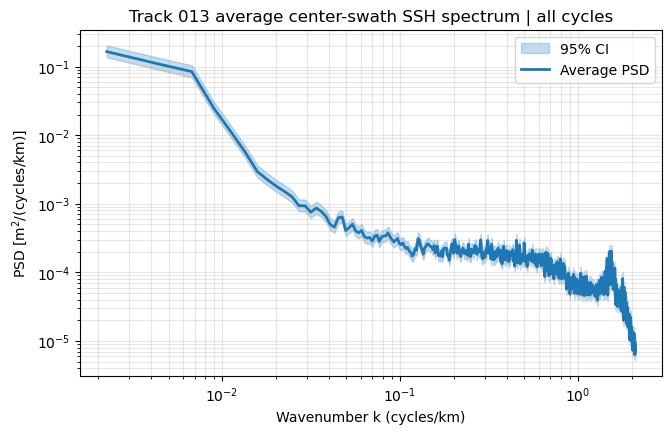

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.fill_between(k_avg_cpkm, psd_lo_95, psd_hi_95, color='tab:blue', alpha=0.25, label='95% CI')
ax.loglog(k_avg_cpkm, avg_psd, color='tab:blue', lw=2.0, label='Average PSD')
ax.set_xlabel('Wavenumber k (cycles/km)')
ax.set_ylabel('PSD [m$^2$/(cycles/km)]')
ax.set_title(f'Track {track_all_cycles:03d} average center-swath SSH spectrum | all cycles')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best')
plt.show()

## Step 5 — Comparison with L3 2 km smoothed data

Load L3 2 km smoothed SSH for the same cycles and compute ensemble spectrum for direct comparison.

In [16]:
# Discover 2 km smoothed files for overlapping cycles
from pathlib import Path

smoothed_root = Path('/project/downloads/Swot/l3_karin_nadir/l3_lr_ssh/v3_0/1day_orbit/')

# Find all 2 km smoothed files for track 013
# Format: SWOT_L3_LR_SSH_Expert_CCC_TTT_...nc
all_t13 = list(sorted(smoothed_root.glob('SWOT_L3_LR_SSH_Expert_*_013_*.nc')))
print(f'Total track 013 files in 2 km smoothed: {len(all_t13)}')

# Extract cycles from all files
# parts[5]=cycle, parts[6]=track
all_cycles_2km = set()
for f in all_t13:
    parts = f.name.split('_')
    if len(parts) >= 7:
        try:
            cyc = int(parts[5])
            trk = int(parts[6])
            if trk == 13:
                all_cycles_2km.add(cyc)
        except (ValueError, IndexError):
            pass

print(f'Cycles in 2 km smoothed data: {sorted(all_cycles_2km)[:20]}... (first 20)')

# Find overlaps with unsmoothed analysis cycles
overlap = set(cycles_represented) & all_cycles_2km
print(f'\nOverlapping cycles: {sorted(overlap)}')

# Build matched file list
smoothed_files_t13 = []
for f in all_t13:
    parts = f.name.split('_')
    if len(parts) >= 7:
        try:
            cyc = int(parts[5])
            if cyc in overlap:
                smoothed_files_t13.append(f)
        except (ValueError, IndexError):
            pass

print(f'\nFound {len(smoothed_files_t13)} 2 km smoothed files matching the overlapping cycles')
if smoothed_files_t13:
    print(f'First file: {smoothed_files_t13[0].name}')
    print(f'Last file: {smoothed_files_t13[-1].name}')

Total track 013 files in 2 km smoothed: 83
Cycles in 2 km smoothed data: [490, 491, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509]... (first 20)

Overlapping cycles: [490, 492, 493, 494, 495, 496, 497, 498, 499, 500, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516, 517, 518, 519, 521, 522, 523, 524, 525, 529, 530]

Found 36 2 km smoothed files matching the overlapping cycles
First file: SWOT_L3_LR_SSH_Expert_490_013_20230414T054520_20230414T063625_v3.0.nc
Last file: SWOT_L3_LR_SSH_Expert_530_013_20230523T233033_20230524T002138_v3.0.nc


In [17]:
import re
import scipy.stats


def parse_cycle_track_swot(path):
    m = re.search(r"_(\d{3})_(\d{3})_\d{8}T", Path(path).name)
    if m is None:
        return None, None
    return int(m.group(1)), int(m.group(2))


def decode_scaled_var(ds, var_name):
    da = ds[var_name]
    arr = da.values.astype(np.float64)
    sf = da.attrs.get("scale_factor", None)
    ao = da.attrs.get("add_offset", None)
    fv = da.attrs.get("_FillValue", None)
    if fv is not None:
        arr[arr == fv] = np.nan
    if sf is not None:
        arr = arr * float(sf)
    if ao is not None:
        arr = arr + float(ao)
    return arr


def longest_true_run(mask):
    idx = np.flatnonzero(mask)
    if idx.size == 0:
        return None
    split = np.where(np.diff(idx) > 1)[0]
    starts = np.r_[0, split + 1]
    stops = np.r_[split + 1, idx.size]
    run_lengths = stops - starts
    i = np.argmax(run_lengths)
    return idx[starts[i]], idx[stops[i] - 1]


def fill_small_gaps_linear(y, max_gap=3):
    """Fill only short NaN gaps by linear interpolation; keep long gaps as NaN."""
    y = np.asarray(y, dtype=np.float64).copy()
    n = y.size
    isn = ~np.isfinite(y)
    if not np.any(isn):
        return y

    i = 0
    while i < n:
        if not isn[i]:
            i += 1
            continue
        j = i
        while j < n and isn[j]:
            j += 1
        gap_len = j - i
        left = i - 1
        right = j
        if (
            gap_len <= max_gap
            and left >= 0
            and right < n
            and np.isfinite(y[left])
            and np.isfinite(y[right])
        ):
            y[i:j] = np.interp(np.arange(i, j), [left, right], [y[left], y[right]])
        i = j
    return y


def cumulative_distance_km(lat, lon):
    lat = np.asarray(lat, dtype=np.float64)
    lon = np.asarray(lon, dtype=np.float64)
    dlat = np.diff(lat)
    dlon = np.diff(lon)
    # Handle antimeridian safely.
    dlon = (dlon + 180.0) % 360.0 - 180.0
    lat_mid = np.deg2rad(0.5 * (lat[:-1] + lat[1:]))
    step = 6371.0 * np.deg2rad(np.sqrt(dlat ** 2 + (np.cos(lat_mid) * dlon) ** 2))
    s = np.r_[0.0, np.cumsum(step)]
    return s, step


def choose_mid_600km_segment(y, lat, lon, min_length_km=600.0):
    s, _ = cumulative_distance_km(lat, lon)
    total = s[-1]
    if total < min_length_km:
        return None
    start_dist = 0.5 * (total - min_length_km)
    end_dist = start_dist + min_length_km
    i0 = int(np.searchsorted(s, start_dist, side="left"))
    i1 = int(np.searchsorted(s, end_dist, side="right")) - 1
    i0 = max(i0, 0)
    i1 = min(i1, len(y) - 1)
    if i1 <= i0:
        return None
    return i0, i1


def offshore_mask_from_swath(ssh_swath, pix, window=2, min_valid_frac=0.7):
    """Reject likely near-coast lines by requiring valid neighbors across-track."""
    n_lines, n_pix = ssh_swath.shape
    p0 = max(0, pix - window)
    p1 = min(n_pix, pix + window + 1)
    valid_frac = np.mean(np.isfinite(ssh_swath[:, p0:p1]), axis=1)
    return valid_frac >= min_valid_frac


def extract_profiles_fixed_length(
    file_list,
    ssh_var,
    lat_var="latitude",
    lon_var="longitude",
    qf_var="quality_flag",
    lat_start=32.0,
    lat_end=41.0,
    qf_max=5,
    min_length_km=600.0,
    gap_max=3,
):
    profiles = []
    profile_cycles = []

    for path in file_list:
        cyc, trk = parse_cycle_track_swot(path)
        if cyc is None:
            continue

        ds = xr.open_dataset(path, decode_times=False)
        try:
            if ssh_var not in ds:
                continue

            ssh = decode_scaled_var(ds, ssh_var)
            lat = decode_scaled_var(ds, lat_var) if lat_var in ds else ds[lat_var].values
            lon = decode_scaled_var(ds, lon_var) if lon_var in ds else ds[lon_var].values
            qf = ds[qf_var].values if qf_var in ds else np.zeros_like(ssh)

            n_lines, n_pix = ssh.shape
            pix_candidates = [int(0.25 * n_pix), int(0.75 * n_pix)]

            for pix in pix_candidates:
                y = ssh[:, pix].astype(np.float64)
                lat_line = lat[:, pix].astype(np.float64)
                lon_line = lon[:, pix].astype(np.float64)
                qf_line = qf[:, pix]

                offshore = offshore_mask_from_swath(ssh, pix, window=2, min_valid_frac=0.7)
                base = (
                    np.isfinite(y)
                    & (qf_line <= qf_max)
                    & (lat_line >= lat_start)
                    & (lat_line <= lat_end)
                    & offshore
                )

                y_work = y.copy()
                y_work[~base] = np.nan
                y_fill = fill_small_gaps_linear(y_work, max_gap=gap_max)

                run = longest_true_run(np.isfinite(y_fill))
                if run is None:
                    continue
                i0, i1 = run

                yy = y_fill[i0 : i1 + 1]
                la = lat_line[i0 : i1 + 1]
                lo = lon_line[i0 : i1 + 1]

                seg = choose_mid_600km_segment(yy, la, lo, min_length_km=min_length_km)
                if seg is None:
                    continue
                j0, j1 = seg

                y_seg = yy[j0 : j1 + 1]
                la_seg = la[j0 : j1 + 1]
                lo_seg = lo[j0 : j1 + 1]
                s_seg, step_seg = cumulative_distance_km(la_seg, lo_seg)
                if y_seg.size < 32:
                    continue

                profiles.append(
                    {
                        "cycle": cyc,
                        "track": trk,
                        "ssh": y_seg,
                        "lat": la_seg,
                        "lon": lo_seg,
                        "dx_km": float(np.nanmedian(step_seg)),
                        "length_km": float(s_seg[-1]),
                    }
                )
                profile_cycles.append(cyc)
        finally:
            ds.close()

    return profiles, sorted(set(profile_cycles))


def spectra_to_common_k(profile_list, n_k=180):
    specs = []
    for p in profile_list:
        y = np.asarray(p["ssh"], dtype=np.float64)
        y = y - np.nanmean(y)
        sp = freq_spec(float(p["dx_km"]), y)
        psd = np.asarray(sp[0], dtype=np.float64)
        k = np.asarray(sp[1], dtype=np.float64)
        m = (k > 0) & np.isfinite(k) & np.isfinite(psd) & (psd > 0)
        if np.count_nonzero(m) < 20:
            continue
        specs.append((k[m], psd[m]))

    if len(specs) < 2:
        return None, None

    kmin = max(s[0][0] for s in specs)
    kmax = min(s[0][-1] for s in specs)
    if not np.isfinite(kmin) or not np.isfinite(kmax) or kmax <= kmin:
        return None, None

    k_common = np.logspace(np.log10(kmin), np.log10(kmax), n_k)
    psd_mat = np.full((n_k, len(specs)), np.nan)

    for j, (k, psd) in enumerate(specs):
        psd_mat[:, j] = 10.0 ** np.interp(
            np.log10(k_common),
            np.log10(k),
            np.log10(psd),
            left=np.nan,
            right=np.nan,
        )

    keep = np.all(np.isfinite(psd_mat), axis=1)
    return k_common[keep], psd_mat[keep, :]


def avg_psd_with_ci(psd_mat, alpha=0.05):
    n_ens = psd_mat.shape[1]
    dof = 2 * n_ens
    mean_psd = np.nanmean(psd_mat, axis=1)
    chi_low = scipy.stats.chi2.ppf(alpha / 2.0, dof)
    chi_high = scipy.stats.chi2.ppf(1.0 - alpha / 2.0, dof)
    ci_low = dof * mean_psd / chi_high
    ci_high = dof * mean_psd / chi_low
    return mean_psd, ci_low, ci_high, dof

In [18]:
# Build matched unsmoothed/smoothed ensembles with fixed >=600 km offshore segments
track_all_cycles = 13

unsmoothed_root = Path('/project/downloads/Swot/L3_unsmoothed/swot_l3_expert/')
smoothed_root = Path('/project/downloads/Swot/l3_karin_nadir/l3_lr_ssh/v3_0/1day_orbit/')

# Unsmoothed files for cycles already used in Step 4.
unsmoothed_all = sorted(unsmoothed_root.rglob('SWOT_L3_LR_SSH_*_013_*.nc'))
unsmoothed_files = []
for f in unsmoothed_all:
    cyc, trk = parse_cycle_track_swot(f)
    if trk == 13 and cyc in cycles_represented:
        unsmoothed_files.append(f)

# Smoothed files available in 1-day orbit archive.
smoothed_all = sorted(smoothed_root.glob('SWOT_L3_LR_SSH_Expert_*_013_*.nc'))
smoothed_files = []
for f in smoothed_all:
    cyc, trk = parse_cycle_track_swot(f)
    if trk == 13 and cyc in cycles_represented:
        smoothed_files.append(f)

unsmoothed_cycles = sorted({parse_cycle_track_swot(f)[0] for f in unsmoothed_files})
smoothed_cycles = sorted({parse_cycle_track_swot(f)[0] for f in smoothed_files})
common_cycles = sorted(set(unsmoothed_cycles) & set(smoothed_cycles))

print(f'Unsmoothed files in prior cycle set: {len(unsmoothed_files)}')
print(f'Smoothed files in prior cycle set:   {len(smoothed_files)}')
print(f'Common cycles available in both:     {len(common_cycles)}')

unsmoothed_files_common = [f for f in unsmoothed_files if parse_cycle_track_swot(f)[0] in common_cycles]
smoothed_files_common = [f for f in smoothed_files if parse_cycle_track_swot(f)[0] in common_cycles]

unsmoothed_profiles, unsmoothed_profile_cycles = extract_profiles_fixed_length(
    unsmoothed_files_common,
    ssh_var='ssha_unfiltered',
    lat_start=32.0,
    lat_end=41.0,
    qf_max=5,
    min_length_km=600.0,
    gap_max=3,
)

smoothed_profiles, smoothed_profile_cycles = extract_profiles_fixed_length(
    smoothed_files_common,
    ssh_var='ssha_unfiltered',
    lat_start=32.0,
    lat_end=41.0,
    qf_max=5,
    min_length_km=600.0,
    gap_max=3,
)

print(f'Unsmoothed usable profiles: {len(unsmoothed_profiles)}')
print(f'Smoothed usable profiles:   {len(smoothed_profiles)}')

# Keep only cycles that produced valid profiles in both products.
usable_common_cycles = sorted(set(unsmoothed_profile_cycles) & set(smoothed_profile_cycles))
unsmoothed_profiles = [p for p in unsmoothed_profiles if p['cycle'] in usable_common_cycles]
smoothed_profiles = [p for p in smoothed_profiles if p['cycle'] in usable_common_cycles]

print(f'Cycles with usable profiles in both: {len(usable_common_cycles)}')
if usable_common_cycles:
    print(f'Cycle span: {usable_common_cycles[0]} to {usable_common_cycles[-1]}')

# Native-support averages (keeps high-k range for unsmoothed).
k_uns_native, psd_uns_native_mat = spectra_to_common_k(unsmoothed_profiles, n_k=260)
k_smo_native, psd_smo_native_mat = spectra_to_common_k(smoothed_profiles, n_k=220)

if (k_uns_native is None) or (k_smo_native is None):
    raise RuntimeError('Insufficient valid spectra for one or both products.')

avg_psd_uns_native, psd_lo_uns_native, psd_hi_uns_native, dof_uns_native = avg_psd_with_ci(psd_uns_native_mat)
avg_psd_smo_native, psd_lo_smo_native, psd_hi_smo_native, dof_smo_native = avg_psd_with_ci(psd_smo_native_mat)

# Matched-support averages (for direct same-k comparison where both have support).
kmin_cmp = max(k_uns_native[0], k_smo_native[0])
kmax_cmp = min(k_uns_native[-1], k_smo_native[-1])
k_cmp = np.logspace(np.log10(kmin_cmp), np.log10(kmax_cmp), 180)

psd_uns_cmp = np.column_stack([
    10.0 ** np.interp(np.log10(k_cmp), np.log10(k_uns_native), np.log10(psd_uns_native_mat[:, j]))
    for j in range(psd_uns_native_mat.shape[1])
])

psd_smo_cmp = np.column_stack([
    10.0 ** np.interp(np.log10(k_cmp), np.log10(k_smo_native), np.log10(psd_smo_native_mat[:, j]))
    for j in range(psd_smo_native_mat.shape[1])
])

avg_psd_uns_cmp, psd_lo_uns_cmp, psd_hi_uns_cmp, dof_uns_cmp = avg_psd_with_ci(psd_uns_cmp)
avg_psd_smo_cmp, psd_lo_smo_cmp, psd_hi_smo_cmp, dof_smo_cmp = avg_psd_with_ci(psd_smo_cmp)

dx_uns_med = np.median([p['dx_km'] for p in unsmoothed_profiles])
dx_smo_med = np.median([p['dx_km'] for p in smoothed_profiles])
nyq_uns = 1.0 / (2.0 * dx_uns_med)
nyq_smo = 1.0 / (2.0 * dx_smo_med)

print(f'Native unsmoothed k-range: {k_uns_native[0]:.4g} to {k_uns_native[-1]:.4g} cycles/km')
print(f'Native smoothed k-range:   {k_smo_native[0]:.4g} to {k_smo_native[-1]:.4g} cycles/km')
print(f'Matched comparison range:  {k_cmp[0]:.4g} to {k_cmp[-1]:.4g} cycles/km ({k_cmp.size} points)')
print(f'Unsmoothed ensemble size: {psd_uns_native_mat.shape[1]}, DOF={dof_uns_native}')
print(f'Smoothed ensemble size:   {psd_smo_native_mat.shape[1]}, DOF={dof_smo_native}')
print(f'Approx Nyquist (unsmoothed): {nyq_uns:.3f} cycles/km')
print(f'Approx Nyquist (smoothed):   {nyq_smo:.3f} cycles/km')
print(f'Median segment length (km): unsmoothed={np.median([p["length_km"] for p in unsmoothed_profiles]):.1f}, smoothed={np.median([p["length_km"] for p in smoothed_profiles]):.1f}')

Unsmoothed files in prior cycle set: 48
Smoothed files in prior cycle set:   36
Common cycles available in both:     36
Unsmoothed usable profiles: 71
Smoothed usable profiles:   72
Cycles with usable profiles in both: 36
Cycle span: 490 to 530
Native unsmoothed k-range: 0.00167 to 2.095 cycles/km
Native smoothed k-range:   0.00167 to 0.2478 cycles/km
Matched comparison range:  0.00167 to 0.2478 cycles/km (180 points)
Unsmoothed ensemble size: 71, DOF=142
Smoothed ensemble size:   72, DOF=144
Approx Nyquist (unsmoothed): 2.098 cycles/km
Approx Nyquist (smoothed):   0.250 cycles/km
Median segment length (km): unsmoothed=599.8, smoothed=598.9


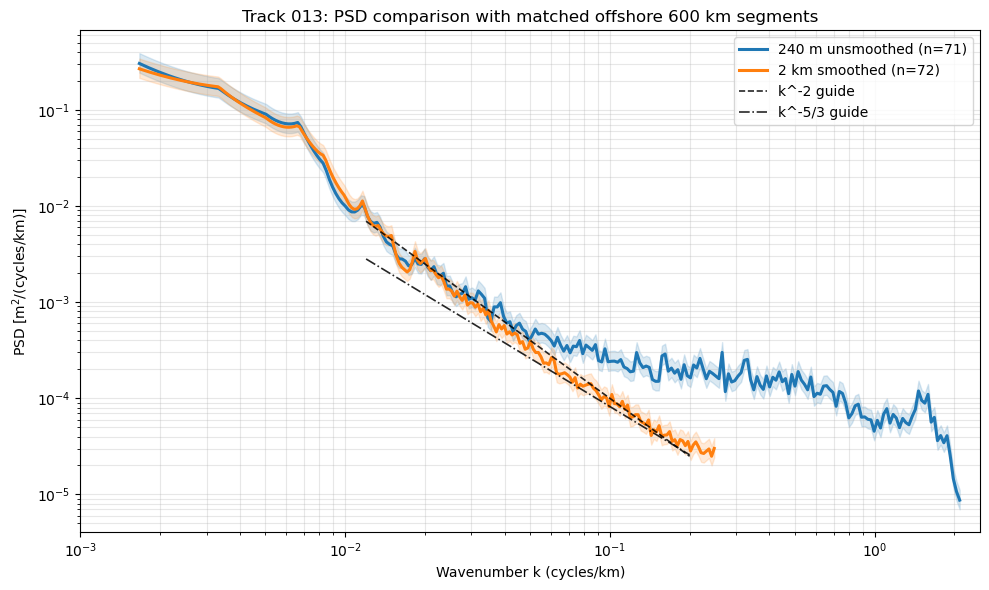

Summary:
  Shared usable cycles: 36
  Unsmoothed profiles:  71
  Smoothed profiles:    72
  Gap filling: linear interpolation only for short gaps (<=3 samples)
  Coastal filter: removed lines with weak cross-track valid support
  Note: smoothed high-k rolloff is expected from 2-km filtering + coarser along-track spacing


In [19]:
# Final comparison plot using native support (retains unsmoothed high-k) + slope guides
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(k_uns_native, psd_lo_uns_native, psd_hi_uns_native, color='tab:blue', alpha=0.16)
ax.fill_between(k_smo_native, psd_lo_smo_native, psd_hi_smo_native, color='tab:orange', alpha=0.16)

ax.loglog(k_uns_native, avg_psd_uns_native, color='tab:blue', lw=2.2, label=f'240 m unsmoothed (n={psd_uns_native_mat.shape[1]})')
ax.loglog(k_smo_native, avg_psd_smo_native, color='tab:orange', lw=2.2, label=f'2 km smoothed (n={psd_smo_native_mat.shape[1]})')

# Slope guides similar to Wave-Vortex style log-log references.
kref = 0.03
iref = np.argmin(np.abs(k_uns_native - kref))
yref = avg_psd_uns_native[iref]
ks = np.array([0.012, 0.20])
ax.loglog(ks, yref * (ks / kref) ** (-2.0), 'k--', lw=1.2, alpha=0.85, label='k^-2 guide')
ax.loglog(ks, 0.55 * yref * (ks / kref) ** (-5.0 / 3.0), 'k-.', lw=1.2, alpha=0.85, label='k^-5/3 guide')

ax.set_xlabel('Wavenumber k (cycles/km)')
ax.set_ylabel('PSD [m$^2$/(cycles/km)]')
ax.set_title('Track 013: PSD comparison with matched offshore 600 km segments')
ax.set_xlim(1e-3, 2.5)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

print('Summary:')
print(f'  Shared usable cycles: {len(usable_common_cycles)}')
print(f'  Unsmoothed profiles:  {len(unsmoothed_profiles)}')
print(f'  Smoothed profiles:    {len(smoothed_profiles)}')
print('  Gap filling: linear interpolation only for short gaps (<=3 samples)')
print('  Coastal filter: removed lines with weak cross-track valid support')
print('  Note: smoothed high-k rolloff is expected from 2-km filtering + coarser along-track spacing')

## Step 6 — Diagnostics for smoothed spectra

These checks show how averaging choices affect smoothness of the 2 km product.

In [20]:
# Fewer-cycle smoothed average (diagnostic)
n_diag_cycles = 8
diag_cycles = usable_common_cycles[:n_diag_cycles]
smoothed_profiles_few = [p for p in smoothed_profiles if p['cycle'] in diag_cycles]

k_smo_few, psd_smo_few_mat = spectra_to_common_k(smoothed_profiles_few, n_k=180)
if k_smo_few is None:
    raise RuntimeError('Not enough smoothed profiles in diagnostic subset.')

avg_psd_smo_few, psd_lo_smo_few, psd_hi_smo_few, dof_smo_few = avg_psd_with_ci(psd_smo_few_mat)

print(f'Diagnostic cycles used: {diag_cycles}')
print(f'Smoothed profiles in fewer-cycle diagnostic: {len(smoothed_profiles_few)}')
print(f'DOF (fewer-cycle): {dof_smo_few}')

Diagnostic cycles used: [490, 492, 493, 494, 495, 496, 497, 498]
Smoothed profiles in fewer-cycle diagnostic: 16
DOF (fewer-cycle): 32


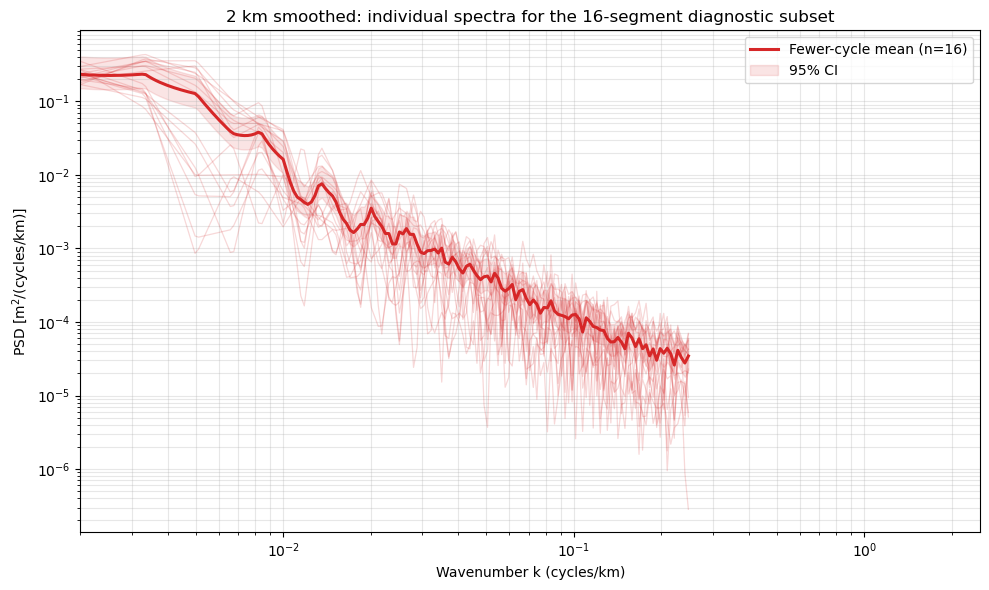

In [21]:
# Plot all individual spectra contributing to the fewer-cycle smoothed average
fig, ax = plt.subplots(figsize=(10, 6))

for j in range(psd_smo_few_mat.shape[1]):
    ax.loglog(k_smo_few, psd_smo_few_mat[:, j], color='tab:red', alpha=0.18, lw=0.9)

ax.loglog(k_smo_few, avg_psd_smo_few, color='tab:red', lw=2.2, label=f'Fewer-cycle mean (n={psd_smo_few_mat.shape[1]})')
ax.fill_between(k_smo_few, psd_lo_smo_few, psd_hi_smo_few, color='tab:red', alpha=0.12, label='95% CI')

ax.set_xlabel('Wavenumber k (cycles/km)')
ax.set_ylabel('PSD [m$^2$/(cycles/km)]')
ax.set_title('2 km smoothed: individual spectra for the 16-segment diagnostic subset')
ax.set_xlim(2e-3, 2.5)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

In [22]:
# Single-segment smoothed spectrum (diagnostic)
smoothed_profiles_sorted = sorted(smoothed_profiles, key=lambda p: (p['cycle'], p['track']))
one_seg = smoothed_profiles_sorted[0]
y_one = one_seg['ssh'] - np.nanmean(one_seg['ssh'])
sp_one = freq_spec(one_seg['dx_km'], y_one, y2=None, win='hann', pad=False)
k_one = np.asarray(sp_one[1])
psd_one = np.asarray(sp_one[0])
m_one = (k_one > 0) & np.isfinite(k_one) & np.isfinite(psd_one) & (psd_one > 0)

print(f"Single-segment cycle: {one_seg['cycle']}, track: {one_seg['track']}")
print(f"Single-segment length: {one_seg['length_km']:.1f} km, dx={one_seg['dx_km']:.3f} km")
print(f"Single-segment Nyquist: {1.0/(2.0*one_seg['dx_km']):.3f} cycles/km")

Single-segment cycle: 490, track: 13
Single-segment length: 599.4 km, dx=2.005 km
Single-segment Nyquist: 0.249 cycles/km


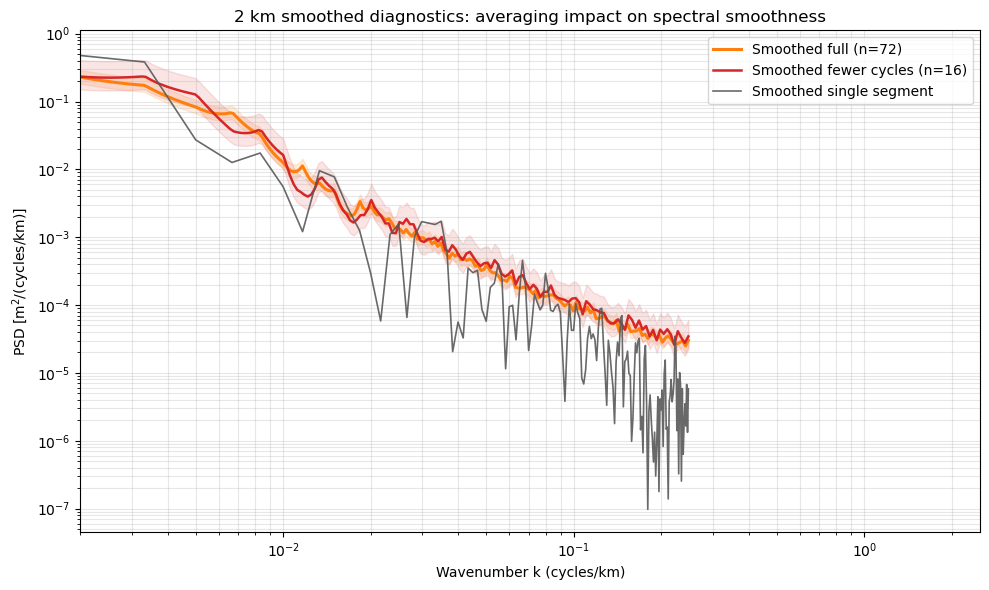

In [23]:
# Compare smoothed: full ensemble vs fewer cycles vs single segment
fig, ax = plt.subplots(figsize=(10, 6))

ax.loglog(k_smo_native, avg_psd_smo_native, color='tab:orange', lw=2.2, label=f'Smoothed full (n={psd_smo_native_mat.shape[1]})')
ax.fill_between(k_smo_native, psd_lo_smo_native, psd_hi_smo_native, color='tab:orange', alpha=0.14)

ax.loglog(k_smo_few, avg_psd_smo_few, color='tab:red', lw=1.8, label=f'Smoothed fewer cycles (n={psd_smo_few_mat.shape[1]})')
ax.fill_between(k_smo_few, psd_lo_smo_few, psd_hi_smo_few, color='tab:red', alpha=0.12)

ax.loglog(k_one[m_one], psd_one[m_one], color='0.35', lw=1.2, alpha=0.9, label='Smoothed single segment')

ax.set_xlabel('Wavenumber k (cycles/km)')
ax.set_ylabel('PSD [m$^2$/(cycles/km)]')
ax.set_title('2 km smoothed diagnostics: averaging impact on spectral smoothness')
ax.set_xlim(2e-3, 2.5)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

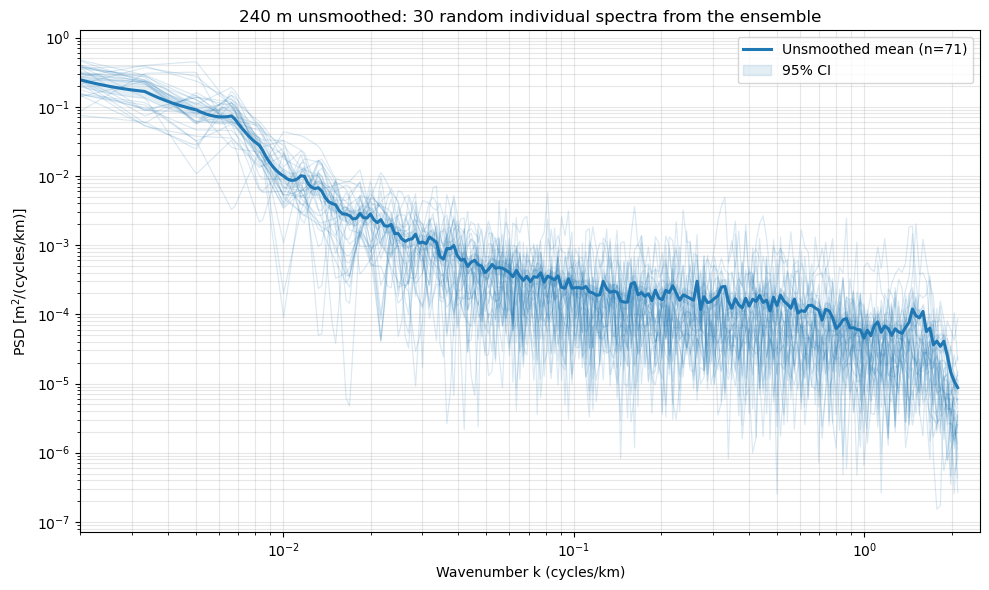

Random unsmoothed members plotted: 30
Selected ensemble indices: [0, 3, 5, 7, 8, 12, 18, 24, 30, 32, 33, 36, 37, 38, 41, 42, 44, 45, 46, 48, 50, 52, 53, 58, 59, 60, 61, 64, 67, 68]


In [24]:
# Plot 30 random individual spectra from the unsmoothed ensemble
rng = np.random.default_rng(13)
n_uns_plot = min(30, psd_uns_native_mat.shape[1])
uns_sel = np.sort(rng.choice(psd_uns_native_mat.shape[1], size=n_uns_plot, replace=False))

fig, ax = plt.subplots(figsize=(10, 6))

for j in uns_sel:
    ax.loglog(k_uns_native, psd_uns_native_mat[:, j], color='tab:blue', alpha=0.16, lw=0.85)

ax.loglog(k_uns_native, avg_psd_uns_native, color='tab:blue', lw=2.2, label=f'Unsmoothed mean (n={psd_uns_native_mat.shape[1]})')
ax.fill_between(k_uns_native, psd_lo_uns_native, psd_hi_uns_native, color='tab:blue', alpha=0.12, label='95% CI')

ax.set_xlabel('Wavenumber k (cycles/km)')
ax.set_ylabel('PSD [m$^2$/(cycles/km)]')
ax.set_title(f'240 m unsmoothed: 30 random individual spectra from the ensemble')
ax.set_xlim(2e-3, 2.5)
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='best')

plt.tight_layout()
plt.show()

print(f'Random unsmoothed members plotted: {n_uns_plot}')
print(f'Selected ensemble indices: {uns_sel.tolist()}')

## Step 7 — Per-cycle left/right-swath average spectra

For each unsmoothed L3 cycle, extract one valid offshore 600 km segment from every usable pixel in the left and right swath halves, average spectra within each side separately, compare a few random cycles, and then plot all cycle-mean spectra for left and right using a cycle colormap.

In [25]:
# Extract all usable left/right-swath segments for each unsmoothed cycle and average by side

def extract_all_swath_segments_for_file(
    path,
    ssh_var='ssha_unfiltered',
    lat_var='latitude',
    lon_var='longitude',
    qf_var='quality_flag',
    lat_start=32.0,
    lat_end=41.0,
    qf_max=5,
    min_length_km=600.0,
    gap_max=3,
    center_exclusion_frac=0.1,
):
    cyc, trk = parse_cycle_track_swot(path)
    if cyc is None:
        return []

    ds = xr.open_dataset(path, decode_times=False)
    try:
        ssh = decode_scaled_var(ds, ssh_var)
        lat = decode_scaled_var(ds, lat_var) if lat_var in ds else ds[lat_var].values
        lon = decode_scaled_var(ds, lon_var) if lon_var in ds else ds[lon_var].values
        qf = ds[qf_var].values if qf_var in ds else np.zeros_like(ssh)

        n_lines, n_pix = ssh.shape
        half = n_pix // 2
        excl = max(1, int(center_exclusion_frac * n_pix))
        left_pixels = np.arange(0, max(0, half - excl))
        right_pixels = np.arange(min(n_pix, half + excl), n_pix)

        results = []
        for swath_side, pix_list in [('left', left_pixels), ('right', right_pixels)]:
            for pix in pix_list:
                y = ssh[:, pix].astype(np.float64)
                lat_line = lat[:, pix].astype(np.float64)
                lon_line = lon[:, pix].astype(np.float64)
                qf_line = qf[:, pix]

                offshore = offshore_mask_from_swath(ssh, int(pix), window=2, min_valid_frac=0.7)
                valid = (
                    np.isfinite(y)
                    & (qf_line <= qf_max)
                    & (lat_line >= lat_start)
                    & (lat_line <= lat_end)
                    & offshore
                )

                y_work = y.copy()
                y_work[~valid] = np.nan
                y_fill = fill_small_gaps_linear(y_work, max_gap=gap_max)
                run = longest_true_run(np.isfinite(y_fill))
                if run is None:
                    continue

                i0, i1 = run
                yy = y_fill[i0:i1 + 1]
                la = lat_line[i0:i1 + 1]
                lo = lon_line[i0:i1 + 1]
                seg = choose_mid_600km_segment(yy, la, lo, min_length_km=min_length_km)
                if seg is None:
                    continue

                j0, j1 = seg
                y_seg = yy[j0:j1 + 1] - np.nanmean(yy[j0:j1 + 1])
                la_seg = la[j0:j1 + 1]
                lo_seg = lo[j0:j1 + 1]
                _, step_seg = cumulative_distance_km(la_seg, lo_seg)
                step_seg = step_seg[np.isfinite(step_seg) & (step_seg > 0)]
                if step_seg.size == 0 or y_seg.size < 32:
                    continue

                results.append({
                    'cycle': cyc,
                    'track': trk,
                    'pixel': int(pix),
                    'side': swath_side,
                    'ssh': y_seg,
                    'dx_km': float(np.median(step_seg)),
                    'length_km': float(np.sum(step_seg)),
                })
    finally:
        ds.close()

    return results


def average_segment_spectra(segment_list, n_k=220):
    spec_list = []
    for seg in segment_list:
        sp = freq_spec(seg['dx_km'], seg['ssh'], y2=None, win='hann', pad=False)
        k = np.asarray(sp[1], dtype=np.float64)
        psd = np.asarray(sp[0], dtype=np.float64)
        m = (k > 0) & np.isfinite(k) & np.isfinite(psd) & (psd > 0)
        if np.count_nonzero(m) < 20:
            continue
        spec_list.append((k[m], psd[m]))

    if len(spec_list) < 2:
        return None

    kmin = max(item[0][0] for item in spec_list)
    kmax = min(item[0][-1] for item in spec_list)
    if not np.isfinite(kmin) or not np.isfinite(kmax) or kmax <= kmin:
        return None

    k_common = np.logspace(np.log10(kmin), np.log10(kmax), n_k)
    psd_mat = np.column_stack([
        10.0 ** np.interp(np.log10(k_common), np.log10(kp), np.log10(pp))
        for kp, pp in spec_list
    ])
    return {
        'k': k_common,
        'psd_mean': np.nanmean(psd_mat, axis=1),
        'n_segments': psd_mat.shape[1],
    }


if 'cycle_segment_dict' not in globals() or not cycle_segment_dict:
    cycle_segment_dict = {}
    for path in unsmoothed_files_common:
        cyc, _ = parse_cycle_track_swot(path)
        segments = extract_all_swath_segments_for_file(path)
        if segments:
            cycle_segment_dict[cyc] = segments

cycle_side_avg = {'left': {}, 'right': {}}
for cyc, segments in cycle_segment_dict.items():
    for side in ('left', 'right'):
        side_segments = [seg for seg in segments if seg['side'] == side]
        side_avg = average_segment_spectra(side_segments, n_k=220)
        if side_avg is not None:
            cycle_side_avg[side][cyc] = side_avg

cycles_with_both_sides = sorted(set(cycle_side_avg['left']) & set(cycle_side_avg['right']))
print(f'Cycles with left averages:  {len(cycle_side_avg["left"])}')
print(f'Cycles with right averages: {len(cycle_side_avg["right"])}')
print(f'Cycles with both sides:     {len(cycles_with_both_sides)}')

if cycles_with_both_sides:
    print('Segments per cycle and side:')
    for cyc in cycles_with_both_sides:
        nleft = cycle_side_avg['left'][cyc]['n_segments']
        nright = cycle_side_avg['right'][cyc]['n_segments']
        print(f'  {cyc}: left={nleft}, right={nright}')

rng_a = np.random.default_rng(21)
rng_b = np.random.default_rng(84)
n_cycle_compare = min(3, len(cycles_with_both_sides))
random_cycles_a = sorted(rng_a.choice(cycles_with_both_sides, size=n_cycle_compare, replace=False).tolist()) if n_cycle_compare else []
random_cycles_b = sorted(rng_b.choice(cycles_with_both_sides, size=n_cycle_compare, replace=False).tolist()) if n_cycle_compare else []
print(f'Random comparison cycles A: {random_cycles_a}')
print(f'Random comparison cycles B: {random_cycles_b}')

Cycles with left averages:  36
Cycles with right averages: 36
Cycles with both sides:     36
Segments per cycle and side:
  490: left=203, right=204
  492: left=203, right=204
  493: left=203, right=204
  494: left=154, right=100
  495: left=202, right=204
  496: left=203, right=204
  497: left=203, right=204
  498: left=203, right=204
  499: left=203, right=204
  500: left=203, right=204
  501: left=203, right=204
  502: left=203, right=204
  503: left=203, right=204
  504: left=203, right=204
  505: left=203, right=204
  506: left=203, right=204
  507: left=198, right=204
  508: left=150, right=132
  509: left=86, right=105
  510: left=199, right=204
  511: left=203, right=204
  512: left=203, right=204
  513: left=203, right=204
  514: left=203, right=204
  515: left=203, right=204
  516: left=203, right=204
  517: left=203, right=204
  518: left=203, right=204
  519: left=203, right=204
  521: left=203, right=204
  522: left=203, right=204
  523: left=203, right=204
  524: left=203

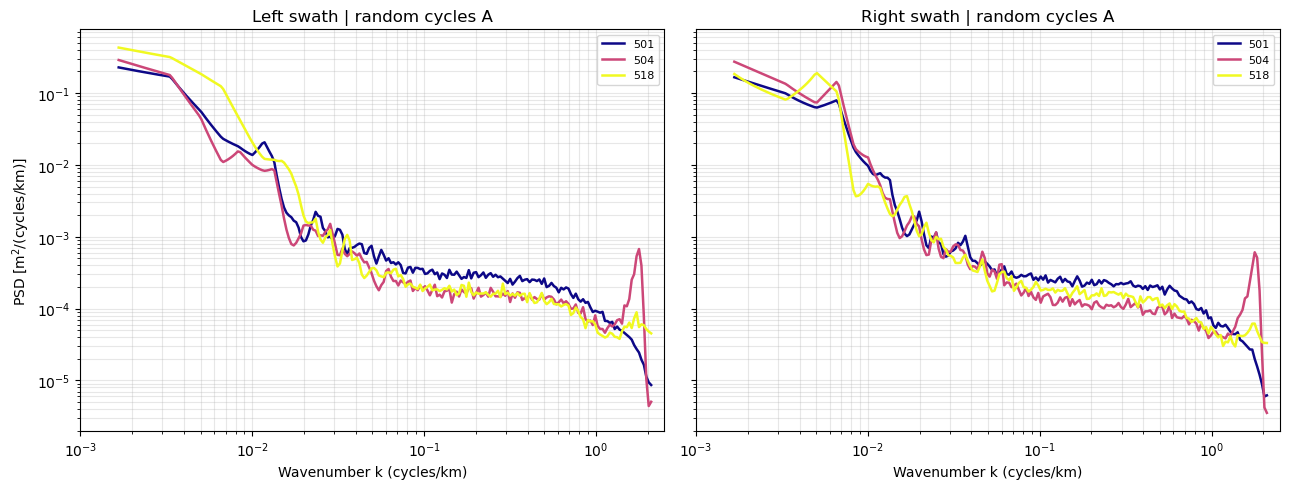

In [26]:
# Compare left and right for 3 random cycles, version A
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cycle_colors = plt.cm.plasma(np.linspace(0, 1, max(1, len(random_cycles_a))))

for color, cyc in zip(cycle_colors, random_cycles_a):
    axes[0].loglog(cycle_side_avg['left'][cyc]['k'], cycle_side_avg['left'][cyc]['psd_mean'], color=color, lw=1.8, label=str(cyc))
    axes[1].loglog(cycle_side_avg['right'][cyc]['k'], cycle_side_avg['right'][cyc]['psd_mean'], color=color, lw=1.8, label=str(cyc))

axes[0].set_title('Left swath | random cycles A')
axes[1].set_title('Right swath | random cycles A')
for ax in axes:
    ax.set_xlabel('Wavenumber k (cycles/km)')
    ax.set_xlim(1e-3, 2.5)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('PSD [m$^2$/(cycles/km)]')
axes[0].legend(loc='best', fontsize=8)
axes[1].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

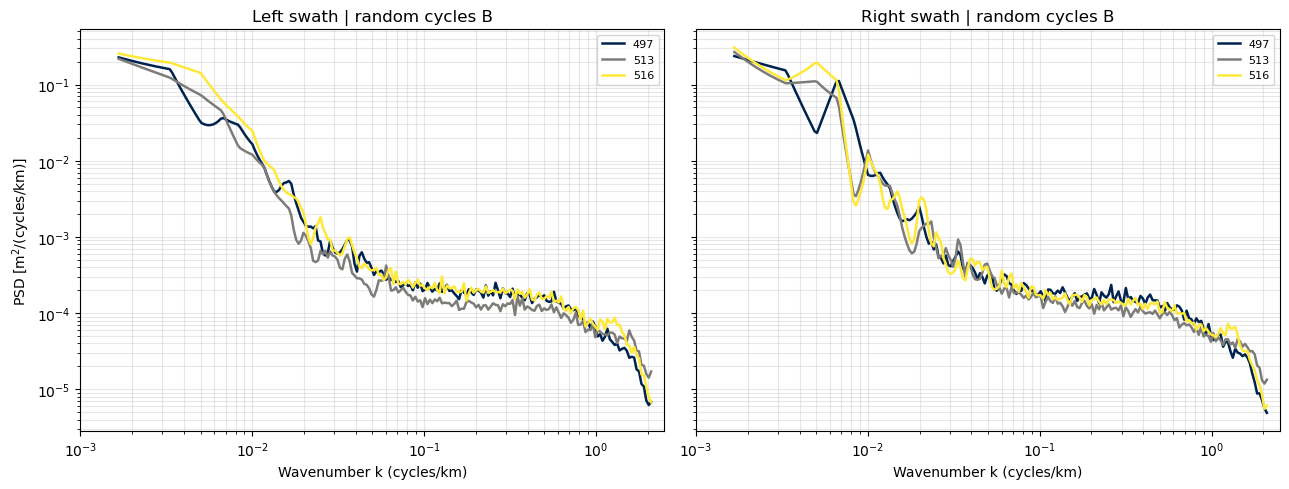

In [27]:
# Compare left and right for 3 random cycles, version B
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
cycle_colors = plt.cm.cividis(np.linspace(0, 1, max(1, len(random_cycles_b))))

for color, cyc in zip(cycle_colors, random_cycles_b):
    axes[0].loglog(cycle_side_avg['left'][cyc]['k'], cycle_side_avg['left'][cyc]['psd_mean'], color=color, lw=1.8, label=str(cyc))
    axes[1].loglog(cycle_side_avg['right'][cyc]['k'], cycle_side_avg['right'][cyc]['psd_mean'], color=color, lw=1.8, label=str(cyc))

axes[0].set_title('Left swath | random cycles B')
axes[1].set_title('Right swath | random cycles B')
for ax in axes:
    ax.set_xlabel('Wavenumber k (cycles/km)')
    ax.set_xlim(1e-3, 2.5)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('PSD [m$^2$/(cycles/km)]')
axes[0].legend(loc='best', fontsize=8)
axes[1].legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

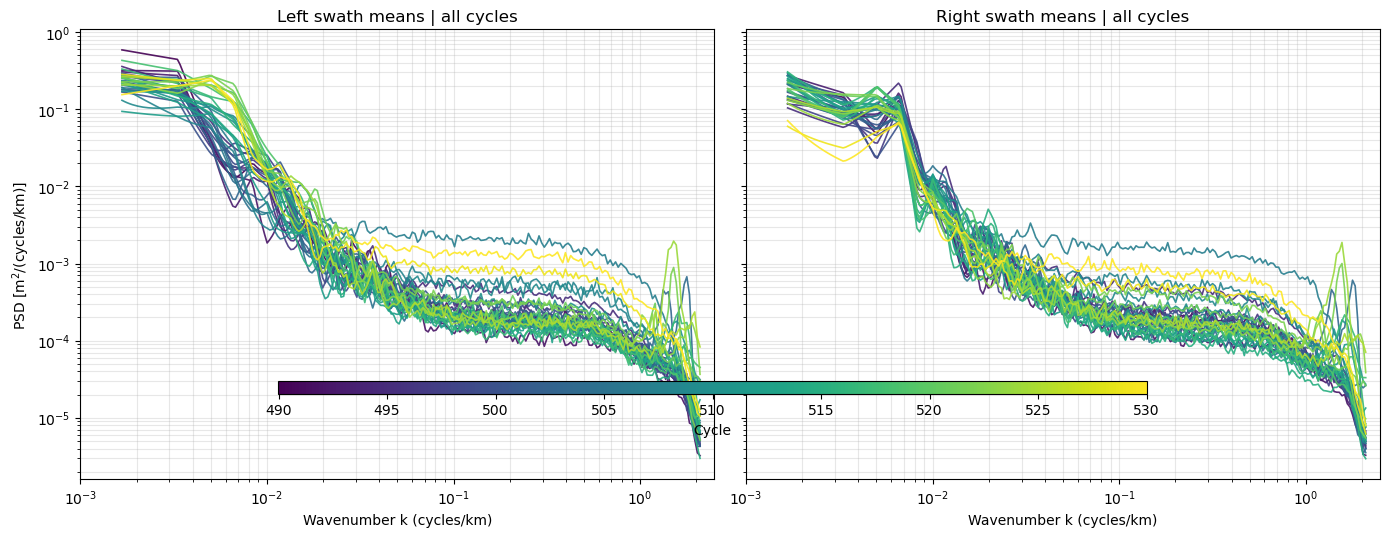

In [28]:
# All-cycle left/right averages with cycle colormap and no legend
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
all_cycles_lr = cycles_with_both_sides
norm = plt.Normalize(min(all_cycles_lr), max(all_cycles_lr))
cmap = plt.cm.viridis

for cyc in all_cycles_lr:
    color = cmap(norm(cyc))
    axes[0].loglog(cycle_side_avg['left'][cyc]['k'], cycle_side_avg['left'][cyc]['psd_mean'], color=color, lw=1.2, alpha=0.9)
    axes[1].loglog(cycle_side_avg['right'][cyc]['k'], cycle_side_avg['right'][cyc]['psd_mean'], color=color, lw=1.2, alpha=0.9)

axes[0].set_title('Left swath means | all cycles')
axes[1].set_title('Right swath means | all cycles')
for ax in axes:
    ax.set_xlabel('Wavenumber k (cycles/km)')
    ax.set_xlim(1e-3, 2.5)
    ax.grid(True, which='both', alpha=0.3)
axes[0].set_ylabel('PSD [m$^2$/(cycles/km)]')

sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), pad=0.02,
                    orientation='horizontal', aspect=70, shrink=0.8)
cbar.set_label('Cycle')

plt.tight_layout()
plt.show()